In [ ]:
import numpy as np #operaciones matemáticas
import matplotlib.pyplot as plt #libreria para gráficar
from matplotlib import animation # libreria para animaciones
from IPython.display import HTML # libreria necesaria para mostrar las animaciones en google colab
import matplotlib as mpl

In [ ]:
def calcular_longitud_onda_newton_raphson(h, omega):

  tol=1e-4
  max_iter=100

  def fenton_mckee(h, omega):
    y = (omega**2) * h / g
    y_34 = y ** 0.75
    coth_y34 = 1 / np.tanh(y_34)
    xi = y * (coth_y34 ** (2/3))
    return xi

  def ecuacion_dispersion(h, omega, xi):
    primer_termino = (omega**2) * (h/g)
    segundo_termino = xi * np.tanh(xi)
    return primer_termino - segundo_termino

  def ecuacion_dispersion_derivada(h, omega, xi):
    cos_hip = np.cosh(xi)
    denominador_primer_termino= cos_hip**2
    primer_termino = (xi/denominador_primer_termino)
    segundo_termino = np.tanh(xi)
    return -primer_termino -segundo_termino

  xi = fenton_mckee(h, omega)

  for i in range(max_iter):
    f = ecuacion_dispersion(h, omega, xi)
    df = ecuacion_dispersion_derivada(h, omega, xi)
    x_nuevo = xi - (f / df)
    if abs(x_nuevo - xi) < tol:
      break
    xi = x_nuevo

  k = xi / h
  L = 2 * np.pi / k

  return k, L

def eta(x, t, H, k, omega):
  eta = (H/2)*np.cos(k*x-omega*t)
  return eta

def factor_n(k, h):
  numerador = 2*k*h
  denominador = np.sinh(2*k*h)

  return (1 + (numerador / denominador))*0.5

In [ ]:
#Datos iniciales
L_t = 5000
g = 9.81
L_plano = (2/3)*5000
h_inicial = 10
H_inicial = 1
T = 25
E_inicial = (1/8)*(H_inicial**2)
omega = 2*np.pi/T

#Función lineal para cambio de altura en la pendiente
def altura(x):
  m = (0.65/100)
  if x < L_plano:
    h = h_inicial
  else:
    h = -(m)*(x-L_plano)+10
  return h

In [ ]:
#Arrays que calculan todas las propiedades de la onda para cada segmento x
dx = 0.1
x = np.arange(0, 5000 +dx, dx)
t_total = 10
x_onda = x[x < 4860]

h_array = np.zeros(len(x_onda))
for i in range(len(x_onda)):
  h_array[i] = altura(x_onda[i])

k_array = np.zeros(len(x_onda))
for i in range(len(x_onda)):
  k_array[i] = calcular_longitud_onda_newton_raphson(h_array[i], omega)[0]

C_array = np.zeros(len(x_onda))
for i in range(len(x_onda)):
  C_array[i] = 2*np.pi/k_array[i]

n_array = np.zeros(len(x_onda))
for i in range(len(x_onda)):
  n_array[i] = factor_n(k_array[i], h_array[i])

Cg_array = np.zeros(len(x_onda))
for i in range(len(x_onda)):
  Cg_array[i] = C_array[i]*n_array[i]


#Flujo de energía se conserva, por lo que solo la proporción entre energía y grupo de onda cambia.
F_inicial = E_inicial*Cg_array[0]

#Se resuelve para H para cada sección de x con la conservación de potencia
H_array = np.zeros(len(x_onda))
for i in range(len(x_onda)):
  H_array[i] = np.sqrt(8*(F_inicial)/(Cg_array[i]))

#Se calcula la proporción de H/h para luego buscar los valores anterirores al rompimiento H/h=0.8
rompimiento_array = np.zeros(len(x_onda))
for i in range(len(x_onda)):
  rompimiento_array[i] = (H_array[i]/h_array[i])

rompimiento_array = rompimiento_array[rompimiento_array<=0.8]

diff = len(x_onda) - len(rompimiento_array)
x_onda_nuevo = x_onda[:-diff]
h_nuevo = h_array[:-diff]

eta_array = np.zeros(len(x_onda_nuevo))
for i in range(len(x_onda_nuevo)):
  eta_array[i] = eta(x_onda_nuevo[i], 0, H_array[i], k_array[i], omega)

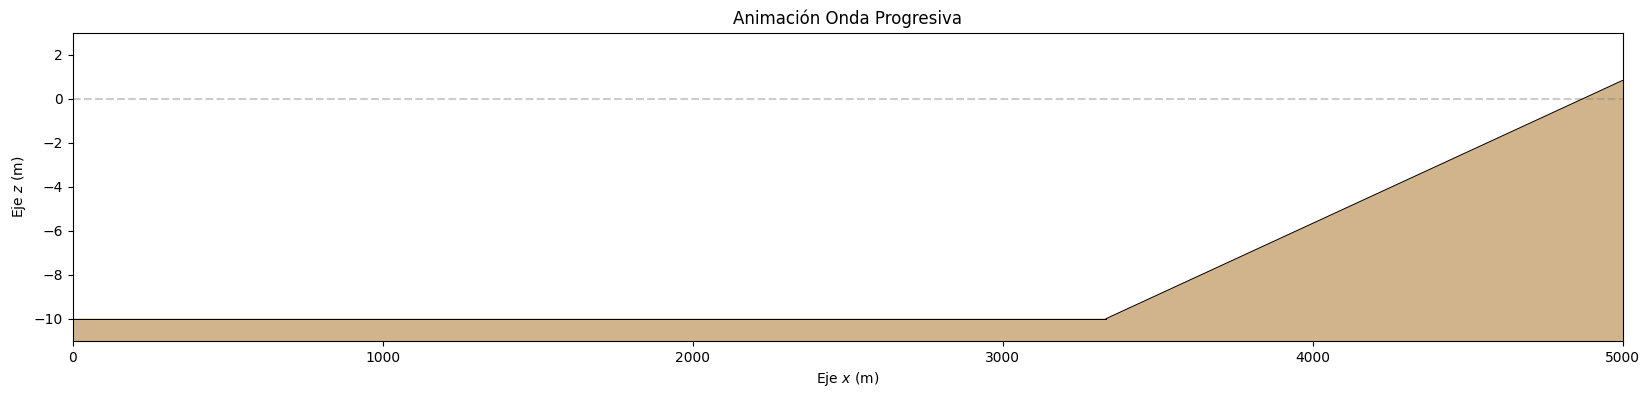

In [ ]:
ancho = 20
alto  = 4
y_limites = [-1.1*h_inicial, 3*H_inicial]

fig, ax = plt.subplots(figsize=(ancho,alto))

ax.set_xlabel('Eje $x$ (m)')
ax.set_ylabel('Eje $z$ (m)')
ax.set_title('Animación Onda Progresiva')
ax.set_xlim(x[0],x[-1])
ax.set_ylim(y_limites[0], y_limites[1])

plt.plot([0, L_t], [0, 0], color='grey', alpha=0.4, linestyle='--')

plt.plot([0, L_plano], [-10, -10], color='black', linewidth=0.7)
plt.plot([L_plano, L_t], [-10, -altura(5000)], color='black', linewidth=0.7)
ax.fill_between(x, y_limites[0], -h_inicial, where=(x <= L_plano), color='tan', alpha=1)

x_fill = x[x > L_plano]
y_fill = -np.array([altura(xi) for xi in x_fill])
ax.fill_between(x_fill, y_limites[0], y_fill, color='tan', alpha=1)


In [ ]:
#Definimos las cosas animadas
line, = ax.plot([],[],linewidth=0.5,color='k')
t = 50
time_text = ax.text(250,1.5*H_inicial,'',fontsize=15)
water = ax.fill_between(x_onda_nuevo,-h_nuevo, np.ones(len(x_onda_nuevo)),color='dodgerblue')

def animate(t):

  for i in range(len(x_onda_nuevo)):
    eta_array[i] = eta(x_onda_nuevo[i], t, H_array[i], k_array[i], omega)

  time_text.set_text('tiempo = %0.0f (s)' % (t,))
  line.set_data(x_onda_nuevo, eta_array)
  #modificamos eta en la superficie libre
  path_water = water.get_paths()[0]
  path_water.vertices[np.size(x_onda_nuevo)+1:2*np.size(x_onda_nuevo)+1, 1] = eta_array[::-1]
  path_water.vertices[0, 1] = eta_array[0]
  path_water.vertices[-1, 1] = eta_array[0]

  return line, time_text

anim = animation.FuncAnimation(fig,animate,frames=t + 1,interval=100,blit=True)
anim.save('Onda_Progresiva.mp4',dpi=300)

HTML(anim.to_jshtml())